# Stage 5 — Results Visualization

Generates publication-quality figures from `experiments/results/combined_results.csv`.

Figures saved to `experiments/results/figures/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

# --- paths ---
RESULTS_CSV = Path("../experiments/results/combined_results.csv")
FIG_DIR = Path("../experiments/results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- global style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
})

METHOD_ORDER  = ["full_cache", "sliding_window", "naive_truncation", "adaptive"]
METHOD_LABELS = ["Full Cache", "Sliding Window", "Naive Truncation", "Adaptive (Ours)"]
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]   # last = red for ours

df = pd.read_csv(RESULTS_CSV)
df["method_label"] = pd.Categorical(
    df["method"].map(dict(zip(METHOD_ORDER, METHOD_LABELS))),
    categories=METHOD_LABELS,
    ordered=True,
)

lb  = df[df["dataset"] == "longbench"].sort_values("method_label")
wt  = df[df["dataset"] == "wikitext-103"].sort_values("method_label")
print("Data loaded:", df.shape)

Data loaded: (8, 10)


## Figure 1 — KV Cache Memory (LongBench)

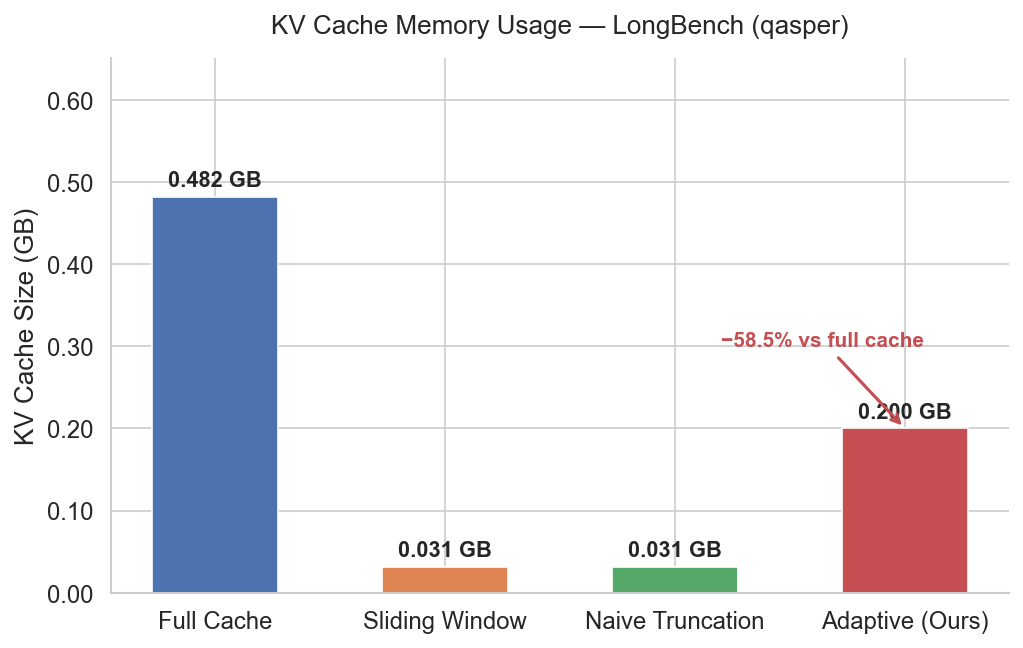

Saved fig1_kv_cache_memory.png


In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    lb["method_label"],
    lb["avg_kv_cache_gb"],
    color=PALETTE,
    edgecolor="white",
    linewidth=0.8,
    width=0.55,
)

# value labels on top
for bar, val in zip(bars, lb["avg_kv_cache_gb"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{val:.3f} GB",
        ha="center", va="bottom", fontsize=10.5, fontweight="bold",
    )

# annotate savings
full_val  = lb.loc[lb["method"] == "full_cache",  "avg_kv_cache_gb"].values[0]
adap_val  = lb.loc[lb["method"] == "adaptive",    "avg_kv_cache_gb"].values[0]
savings_pct = (full_val - adap_val) / full_val * 100
ax.annotate(
    f"−{savings_pct:.1f}% vs full cache",
    xy=(3, adap_val), xytext=(2.2, adap_val + 0.10),
    arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.5),
    fontsize=10, color="#C44E52", fontweight="bold",
)

ax.set_ylabel("KV Cache Size (GB)")
ax.set_title("KV Cache Memory Usage — LongBench (qasper)", pad=12)
ax.set_ylim(0, full_val * 1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
sns.despine(left=False, bottom=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_kv_cache_memory.png")
plt.show()
print("Saved fig1_kv_cache_memory.png")

## Figure 2 — Quality vs Efficiency Tradeoff (LongBench)

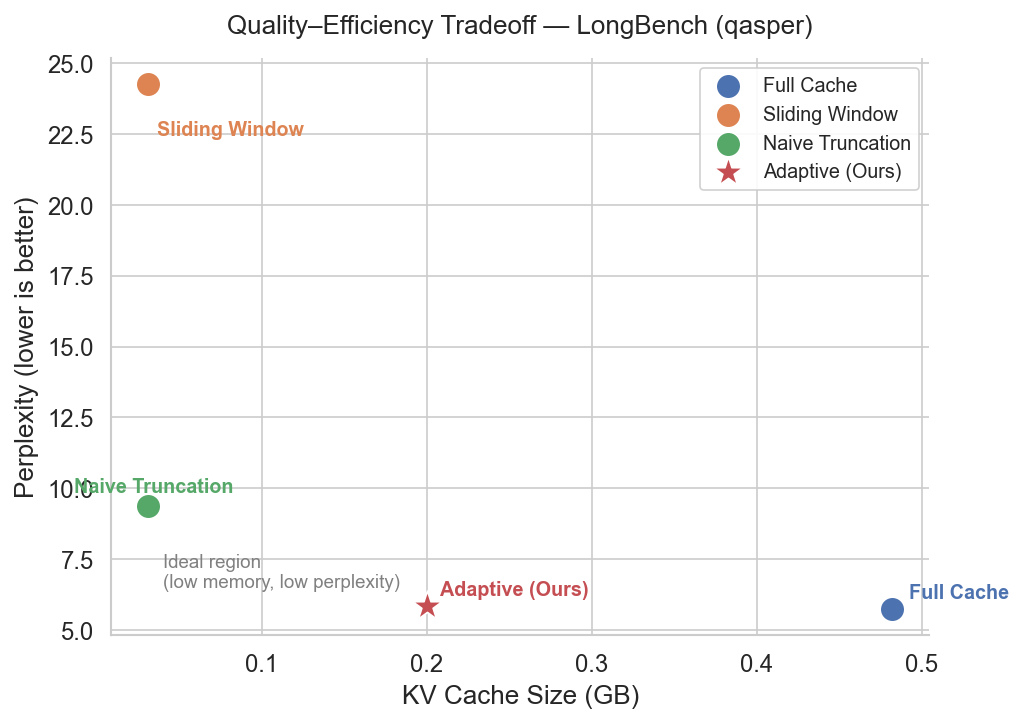

Saved fig2_tradeoff_scatter.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

for i, (method, label, color) in enumerate(zip(METHOD_ORDER, METHOD_LABELS, PALETTE)):
    row = lb[lb["method"] == method].iloc[0]
    size = 220 if method == "adaptive" else 140
    marker = "*" if method == "adaptive" else "o"
    ax.scatter(
        row["avg_kv_cache_gb"], row["perplexity"],
        s=size, color=color, marker=marker,
        zorder=5, label=label,
        edgecolors="white", linewidths=0.8,
    )
    # offset labels to avoid overlap
    offsets = {
        "full_cache":        ( 0.010,  0.4),
        "sliding_window":    ( 0.005, -1.8),
        "naive_truncation":  (-0.045,  0.5),
        "adaptive":          ( 0.008,  0.4),
    }
    dx, dy = offsets[method]
    ax.text(
        row["avg_kv_cache_gb"] + dx,
        row["perplexity"] + dy,
        label, fontsize=9.5, color=color, fontweight="bold",
    )

# ideal corner annotation
ax.annotate(
    "Ideal region\n(low memory, low perplexity)",
    xy=(0.04, 6.5), fontsize=9, color="gray",
    ha="left",
)
ax.annotate(", ", xy=(0, 0), xycoords="axes fraction", fontsize=0)  # dummy to avoid warning

ax.set_xlabel("KV Cache Size (GB)")
ax.set_ylabel("Perplexity (lower is better)")
ax.set_title("Quality–Efficiency Tradeoff — LongBench (qasper)", pad=12)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.9)
sns.despine()

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_tradeoff_scatter.png")
plt.show()
print("Saved fig2_tradeoff_scatter.png")

## Figure 3 — Perplexity Comparison (Both Datasets)

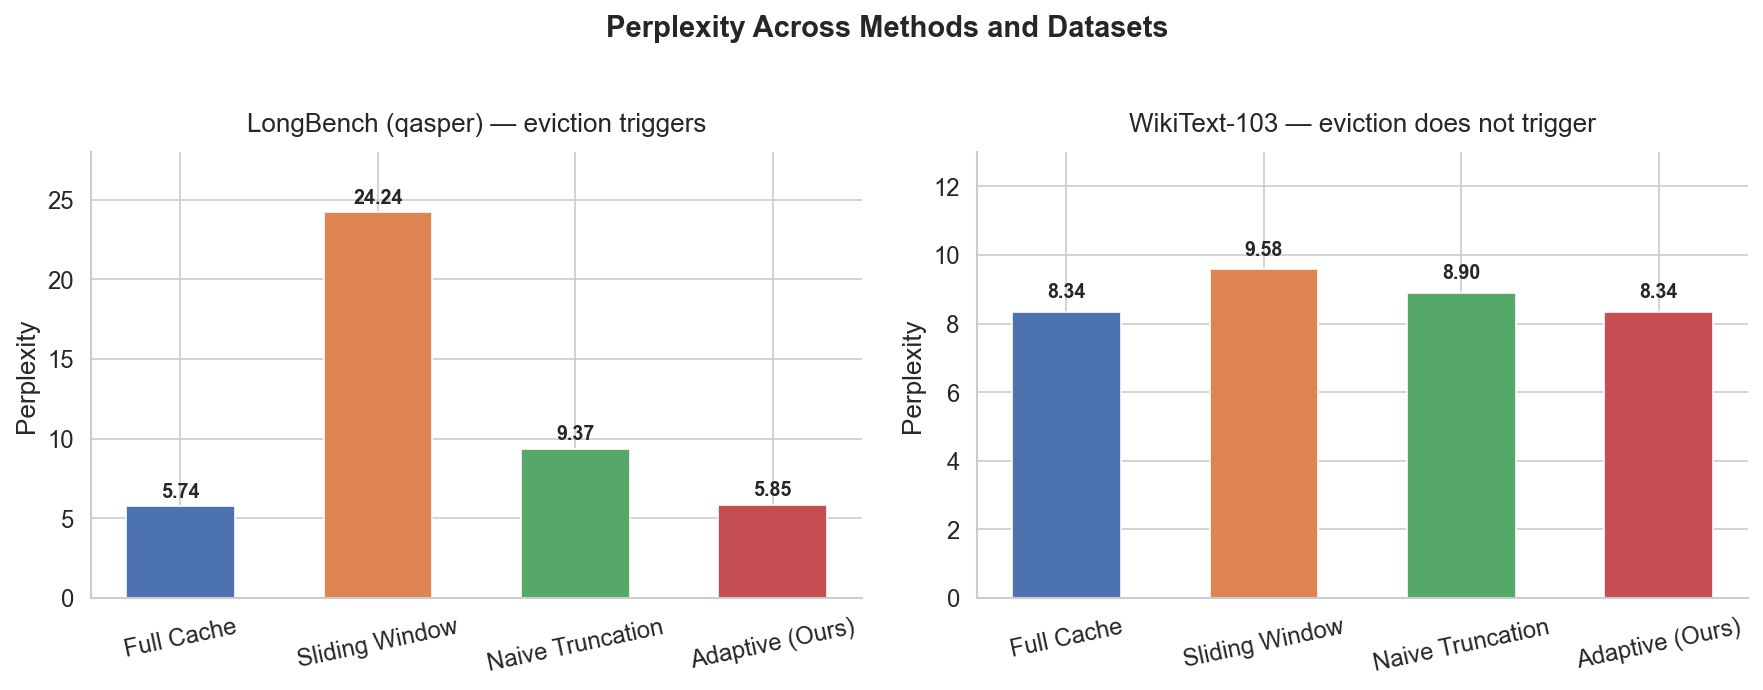

Saved fig3_perplexity_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, subset, title, ylim in zip(
    axes,
    [lb, wt],
    ["LongBench (qasper) — eviction triggers",
     "WikiText-103 — eviction does not trigger"],
    [(0, 28), (0, 13)],
):
    bars = ax.bar(
        subset["method_label"],
        subset["perplexity"],
        color=PALETTE,
        edgecolor="white",
        linewidth=0.8,
        width=0.55,
    )
    for bar, val in zip(bars, subset["perplexity"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold",
        )
    ax.set_ylabel("Perplexity")
    ax.set_title(title, pad=10)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="x", labelrotation=12)
    sns.despine(ax=ax)

fig.suptitle("Perplexity Across Methods and Datasets", y=1.02, fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_perplexity_comparison.png")
plt.show()
print("Saved fig3_perplexity_comparison.png")

## Figure 4 — Latency & Throughput (LongBench)

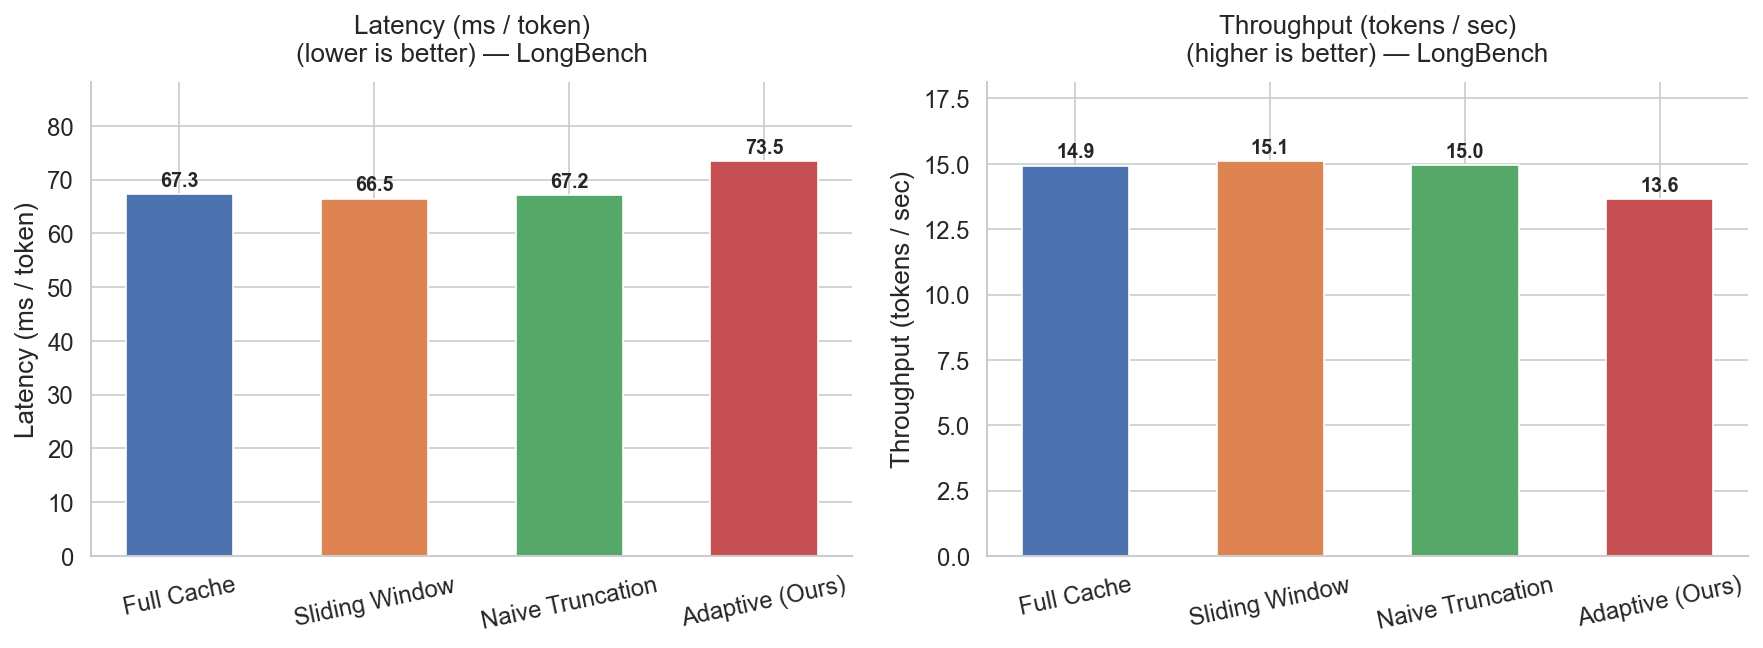

Saved fig4_latency_throughput.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

metrics = [
    ("avg_latency_ms_per_token", "Latency (ms / token)",  "lower is better"),
    ("avg_throughput_tokens_per_sec", "Throughput (tokens / sec)", "higher is better"),
]

for ax, (col, ylabel, note) in zip(axes, metrics):
    bars = ax.bar(
        lb["method_label"],
        lb[col],
        color=PALETTE,
        edgecolor="white",
        linewidth=0.8,
        width=0.55,
    )
    for bar, val in zip(bars, lb[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + lb[col].max() * 0.01,
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold",
        )
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n({note}) — LongBench", pad=10)
    ax.set_ylim(0, lb[col].max() * 1.2)
    ax.tick_params(axis="x", labelrotation=12)
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_latency_throughput.png")
plt.show()
print("Saved fig4_latency_throughput.png")

## Summary

In [6]:
print("Generated figures:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(" ", f.name)

Generated figures:
  fig1_kv_cache_memory.png
  fig2_tradeoff_scatter.png
  fig3_perplexity_comparison.png
  fig4_latency_throughput.png
